In [ ]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers as KL
from tensorflow.keras import Model
import neurite as ne

2025-10-24 16:21:30.622845: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-24 16:21:30.622894: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-24 16:21:30.624256: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [ ]:
npz = np.load('../Data/tutorial_data.npz')
x_train = npz['train'].astype('float32')
x_val = npz['validate'].astype('float32')

vol_shape = x_train.shape[1:]
print("train shape:", x_train.shape, "vol_shape:", vol_shape)

train shape: (208, 192, 160) vol_shape: (192, 160)


In [3]:
def vxm_data_generator(x_data, batch_size=8):
    vol_shape = x_data.shape[1:]
    ndims = len(vol_shape)
    zero_phi = np.zeros([batch_size, *vol_shape, ndims], dtype=np.float32)

    while True:
        idx1 = np.random.randint(0, x_data.shape[0], size=batch_size)
        idx2 = np.random.randint(0, x_data.shape[0], size=batch_size)
        moving = x_data[idx1, ..., np.newaxis]
        fixed  = x_data[idx2, ..., np.newaxis]
        yield [moving, fixed], [fixed, zero_phi]

In [ ]:
class SpatialTransformer(KL.Layer):
    def __init__(self, name='vxm_dense_transformer', **kwargs):
        super().__init__(name=name, **kwargs)

    def call(self, inputs):
        src, flow = inputs 
        B = tf.shape(src)[0]
        H = tf.shape(src)[1]
        W = tf.shape(src)[2]

        ys = tf.cast(tf.range(H), tf.float32)
        xs = tf.cast(tf.range(W), tf.float32)
        yy, xx = tf.meshgrid(ys, xs, indexing='ij')
        grid = tf.stack([xx, yy], axis=-1)
        grid = tf.expand_dims(grid, axis=0)
        grid = tf.tile(grid, [B, 1, 1, 1])

        pts = grid + flow
        x = pts[..., 0]
        y = pts[..., 1]

        x0 = tf.floor(x)
        x1 = x0 + 1.0
        y0 = tf.floor(y)
        y1 = y0 + 1.0

        x0c = tf.clip_by_value(tf.cast(x0, tf.int32), 0, W-1)
        x1c = tf.clip_by_value(tf.cast(x1, tf.int32), 0, W-1)
        y0c = tf.clip_by_value(tf.cast(y0, tf.int32), 0, H-1)
        y1c = tf.clip_by_value(tf.cast(y1, tf.int32), 0, H-1)

        def gather(bi, yi, xi):
            idx = tf.stack([bi, yi, xi], axis=-1)
            return tf.gather_nd(src, idx)

        b = tf.reshape(tf.range(B), [B, 1, 1])
        b = tf.tile(b, [1, H, W])

        Ia = gather(b, y0c, x0c)
        Ib = gather(b, y0c, x1c)
        Ic = gather(b, y1c, x0c)
        Id = gather(b, y1c, x1c)

        x0f = tf.cast(x0, tf.float32)
        x1f = tf.cast(x1, tf.float32)
        y0f = tf.cast(y0, tf.float32)
        y1f = tf.cast(y1, tf.float32)

        wa = (x1f - x) * (y1f - y)
        wb = (x - x0f) * (y1f - y)
        wc = (x1f - x) * (y - y0f)
        wd = (x - x0f) * (y - y0f)

        wa = tf.expand_dims(wa, axis=-1)
        wb = tf.expand_dims(wb, axis=-1)
        wc = tf.expand_dims(wc, axis=-1)
        wd = tf.expand_dims(wd, axis=-1)

        warped = wa*Ia + wb*Ib + wc*Ic + wd*Id
        return warped

In [ ]:
def flow_grad_l2(y_true, flow):
    dx = flow[:, :, 1:, :] - flow[:, :, :-1, :]
    dy = flow[:, 1:, :, :] - flow[:, :-1, :, :]
    dx = tf.pad(dx, [[0,0],[0,0],[0,1],[0,0]])
    dy = tf.pad(dy, [[0,0],[0,1],[0,0],[0,0]])
    return tf.reduce_mean(tf.square(dx)) + tf.reduce_mean(tf.square(dy))

In [ ]:
def build_vxm_dense_2d(vol_shape, enc_feats=(32,32,32,32), final_feats=(32,16),
                       model_name='vxm_dense'):
    H, W = vol_shape

    src = KL.Input((H, W, 1), name='vxm_dense_source_input')
    tgt = KL.Input((H, W, 1), name='vxm_dense_target_input')

    x = KL.Concatenate(name='vxm_dense_unet_input_concat')([src, tgt])

    skips = []
    for i, nf in enumerate(enc_feats):
        x = KL.Conv2D(nf, 3, padding='same', kernel_initializer='he_normal',
                      name=f'vxm_dense_unet_enc_conv_{i}_0')(x)
        x = KL.LeakyReLU(alpha=0.2, name=f'vxm_dense_unet_enc_conv_{i}_0_activation')(x)
        skips.append(x)
        x = KL.MaxPool2D(pool_size=2, name=f'vxm_dense_unet_enc_pooling_{i}')(x)

    x = KL.Conv2D(enc_feats[-1], 3, padding='same', kernel_initializer='he_normal',
                  name='vxm_dense_unet_bottleneck_conv_0')(x)
    x = KL.LeakyReLU(alpha=0.2, name='vxm_dense_unet_bottleneck_conv_0_activation')(x)

    for i, skip in enumerate(reversed(skips)):
        x = KL.UpSampling2D(size=2, interpolation='nearest',
                            name=f'vxm_dense_unet_dec_upsample_{i}')(x)
        x = KL.Concatenate(name=f'vxm_dense_unet_dec_concat_{i}')([x, skip])
        x = KL.Conv2D(skip.shape[-1], 3, padding='same', kernel_initializer='he_normal',
                      name=f'vxm_dense_unet_dec_conv_{i}_0')(x)
        x = KL.LeakyReLU(alpha=0.2, name=f'vxm_dense_unet_dec_conv_{i}_0_activation')(x)

    x = KL.Conv2D(final_feats[0], 3, padding='same', kernel_initializer='he_normal',
                  name='vxm_dense_unet_dec_final_conv_0')(x)
    x = KL.LeakyReLU(alpha=0.2, name='vxm_dense_unet_dec_final_conv_0_activation')(x)

    x = KL.Conv2D(final_feats[1], 3, padding='same', kernel_initializer='he_normal',
                  name='vxm_dense_unet_dec_final_conv_1')(x)
    x = KL.LeakyReLU(alpha=0.2, name='vxm_dense_unet_dec_final_conv_1_activation')(x)

    flow = KL.Conv2D(2, 3, padding='same', kernel_initializer='zeros',
                     name='vxm_dense_flow')(x)

    moved = SpatialTransformer(name='vxm_dense_transformer')([src, flow])

    return Model(inputs=[src, tgt], outputs=[moved, flow], name=model_name)

In [ ]:
model = build_vxm_dense_2d(vol_shape, enc_feats=(32,32,32,32), final_feats=(32,16), model_name='vxm_dense')

losses = ['mse', flow_grad_l2]
loss_weights = [1.0, 0.01]

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=losses,
    loss_weights=loss_weights
)

model.summary(line_length=140)

Model: "vxm_dense"
____________________________________________________________________________________________________________________________________________
 Layer (type)                             Output Shape                              Param #       Connected to                              
 vxm_dense_source_input (InputLayer)      [(None, 192, 160, 1)]                     0             []                                        
                                                                                                                                            
 vxm_dense_target_input (InputLayer)      [(None, 192, 160, 1)]                     0             []                                        
                                                                                                                                            
 vxm_dense_unet_input_concat (Concatenat  (None, 192, 160, 2)                       0             ['vxm_dense_source_input[0][0]',     

In [ ]:
train_gen = vxm_data_generator(x_train, batch_size=1)
(ins_moving, ins_fixed), (tgt_fixed, tgt_zero) = next(train_gen)

pred_moved, pred_flow = model.predict([ins_moving, ins_fixed], verbose=0)
print("moved:", pred_moved.shape, "flow:", pred_flow.shape)

moved: (1, 192, 160, 1) flow: (1, 192, 160, 2)


In [9]:
batch_size = 8
steps_per_epoch = 32
epochs = 800 

train_gen = vxm_data_generator(x_train, batch_size=batch_size)

hist = model.fit(
    train_gen,
    epochs=epochs,
    steps_per_epoch=steps_per_epoch,
    verbose=2
)

Epoch 1/800


I0000 00:00:1761315696.185943   44937 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


32/32 - 5s - loss: 0.0069 - vxm_dense_transformer_loss: 0.0069 - vxm_dense_flow_loss: 8.9316e-05 - 5s/epoch - 143ms/step
Epoch 2/800
32/32 - 0s - loss: 0.0072 - vxm_dense_transformer_loss: 0.0072 - vxm_dense_flow_loss: 2.0947e-04 - 484ms/epoch - 15ms/step
Epoch 3/800
32/32 - 0s - loss: 0.0069 - vxm_dense_transformer_loss: 0.0069 - vxm_dense_flow_loss: 1.5664e-04 - 499ms/epoch - 16ms/step
Epoch 4/800
32/32 - 0s - loss: 0.0068 - vxm_dense_transformer_loss: 0.0068 - vxm_dense_flow_loss: 3.1295e-04 - 488ms/epoch - 15ms/step
Epoch 5/800
32/32 - 0s - loss: 0.0064 - vxm_dense_transformer_loss: 0.0063 - vxm_dense_flow_loss: 0.0050 - 484ms/epoch - 15ms/step
Epoch 6/800
32/32 - 0s - loss: 0.0053 - vxm_dense_transformer_loss: 0.0050 - vxm_dense_flow_loss: 0.0324 - 480ms/epoch - 15ms/step
Epoch 7/800
32/32 - 0s - loss: 0.0050 - vxm_dense_transformer_loss: 0.0045 - vxm_dense_flow_loss: 0.0521 - 497ms/epoch - 16ms/step
Epoch 8/800
32/32 - 0s - loss: 0.0047 - vxm_dense_transformer_loss: 0.0041 - vxm_

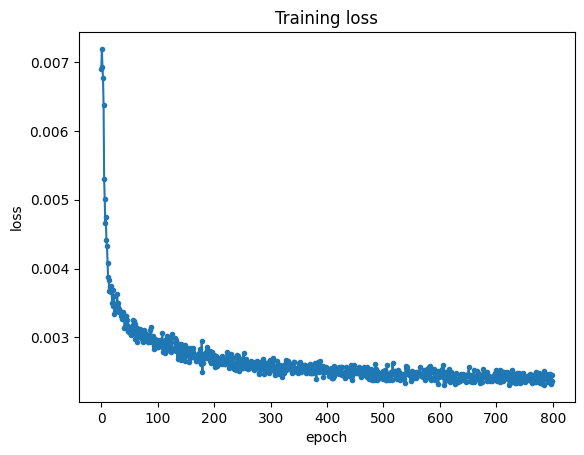

In [ ]:
plt.figure()
plt.plot(hist.epoch, hist.history['loss'], '.-')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Training loss')
plt.show()

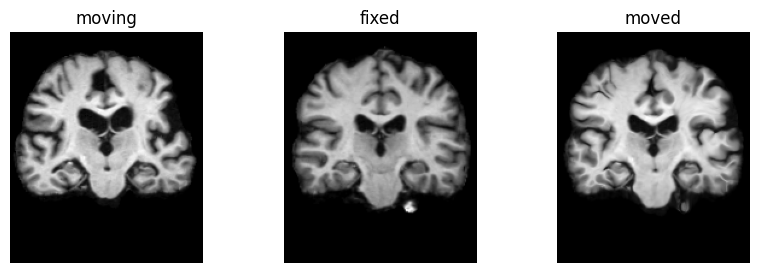

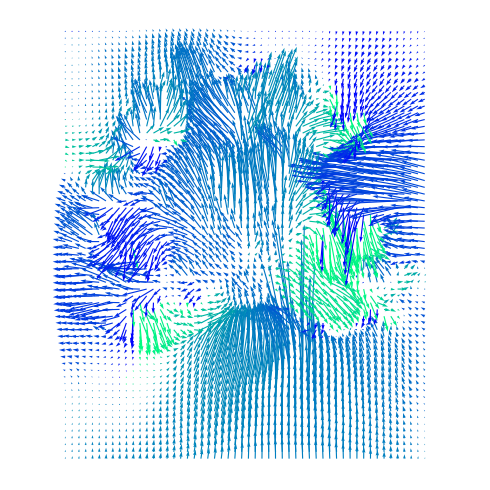

(<Figure size 500x500 with 1 Axes>, [<Axes: >])

In [ ]:
val_gen = vxm_data_generator(x_val, batch_size=1)
val_in, _ = next(val_gen)
val_moved, val_flow = model.predict(val_in, verbose=0)

moving = val_in[0][0, :, :, 0]
fixed  = val_in[1][0, :, :, 0]
moved  = val_moved[0, :, :, 0]
flow   = val_flow[0]

plt.figure(figsize=(10,3))
for i, (img, title) in enumerate([(moving, 'moving'), (fixed, 'fixed'), (moved, 'moved')]):
    plt.subplot(1,3,i+1)
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
plt.show()

flow = val_flow[0]

step = 3
flow_ds = flow[::step, ::step, :]

ne.plot.flow([flow_ds], width=5)